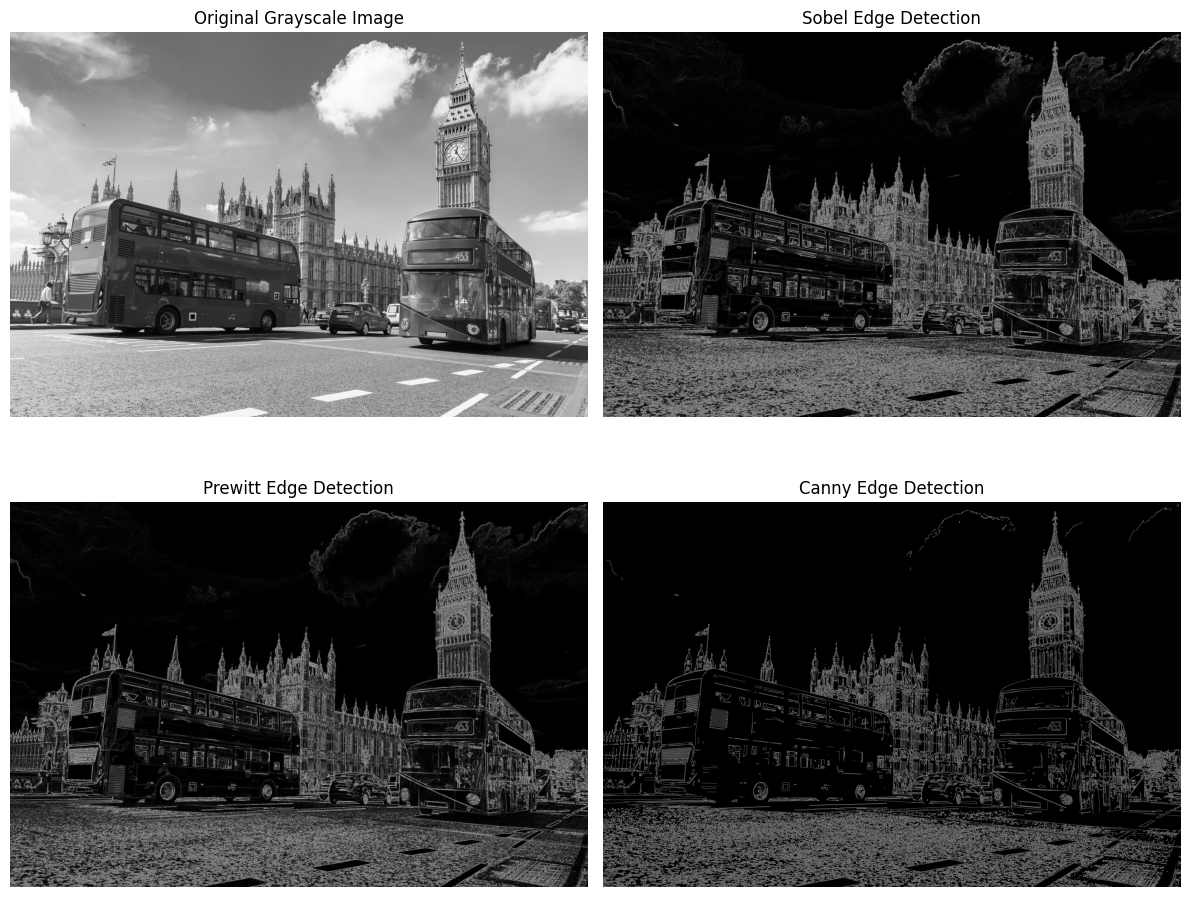

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def show_comparision(original, sobel, prewitt, canny):
  plt.figure(figsize=(12, 10))
  plt.subplot(2, 2, 1)
  plt.imshow(original, cmap='gray')
  plt.title("Original Grayscale Image")
  plt.axis('off')

  plt.subplot(2, 2, 2)
  plt.imshow(sobel, cmap='gray')
  plt.title("Sobel Edge Detection")
  plt.axis('off')

  plt.subplot(2, 2, 3)
  plt.imshow(prewitt, cmap='gray')
  plt.title("Prewitt Edge Detection")
  plt.axis('off')

  plt.subplot(2, 2, 4)
  plt.imshow(canny, cmap='gray')
  plt.title("Canny Edge Detection")
  plt.axis('off')

  plt.tight_layout()
  plt.show()

if __name__ == "__main__":
  img_path = '/content/drive/MyDrive/londres-shutterstock_583939735_zxwj4p.avif'
  img = cv2.imread(img_path, 0)

  if img is None:
    print(f"Error: Image not found at {img_path}")
  else:
    sobelx = cv2.Sobel(img, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(img, cv2.CV_64F, 0, 1, ksize=3)
    sobel_combined = cv2.magnitude(sobelx, sobely)

    kernelx = np.array([[1, 1, 1], [0, 0, 0], [-1, -1, -1]])
    kernely = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])

    prewitt_x = cv2.filter2D(img, cv2.CV_64F, kernelx)
    prewitt_y = cv2.filter2D(img, cv2.CV_64F, kernely)
    prewitt_combined = cv2.magnitude(prewitt_x, prewitt_y)

    canny = cv2.Canny(img, 100, 200)

    original_display = img
    sobel_display = np.uint8(np.absolute(sobel_combined))
    prewitt_display = np.uint8(np.absolute(prewitt_combined))
    canny_display = canny

    show_comparision(original_display, sobel_display, prewitt_display, canny_display)